<a href="https://colab.research.google.com/github/harini-3005/Oasis-Infobyte-task-5/blob/main/task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Housing.csv to Housing.csv
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 

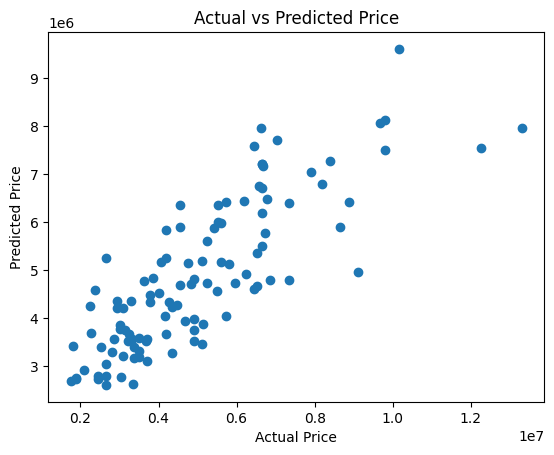

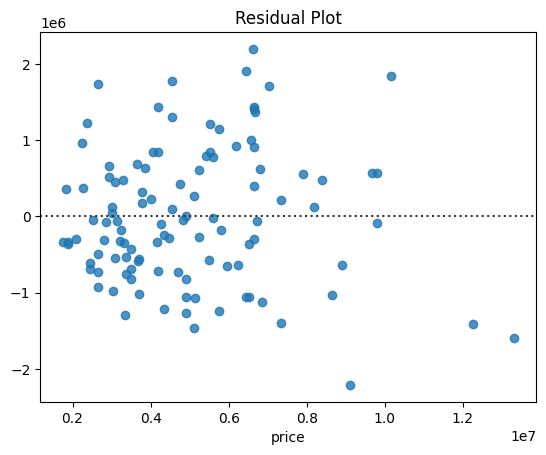


House Price Prediction Completed Successfully!


In [ ]:
# =====================================
# HOUSE PRICE PREDICTION - LINEAR REGRESSION
# =====================================

# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 2. Upload Dataset
from google.colab import files
uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

# 3. Explore Dataset
print(df.head())
print(df.info())
print(df.isnull().sum())

# =====================================
# 🧹 DATA CLEANING
# =====================================

# Fill missing numeric with median
df.fillna(df.median(numeric_only=True), inplace=True)

# Convert categorical columns using encoding
cat_cols = ['mainroad','guestroom','basement','hotwaterheating',
            'airconditioning','prefarea','furnishingstatus']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# =====================================
# 📊 FEATURE & TARGET
# =====================================
X = df.drop('price', axis=1)
y = df['price']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# =====================================
# 🤖 MODEL TRAINING
# =====================================
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# =====================================
# 📈 MODEL EVALUATION
# =====================================
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error:", mse)
print("R2 Score:", r2)

# =====================================
# 📊 VISUALIZATION
# =====================================

# Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")
plt.show()

# Residual Plot
plt.figure()
sns.residplot(x=y_test, y=y_pred)
plt.title("Residual Plot")
plt.show()

print("\nHouse Price Prediction Completed Successfully!")
